# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
import networkx as nx

# Data

In [2]:
student_observations = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='Student_Observations')
student_roster = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='Student_Roster')
class_plan = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='Class_Plan')
kc_coverage = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='KC_Coverage')
overall_scores = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='Overall_Scores')
kc_edges = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='KC_Edges')
kc_nodes = pd.read_excel('../data/raw/final_data.xlsx', sheet_name='KC_Nodes')

# Insights

This dataset contains :

In [3]:
all_students = student_observations['student_id'].unique()
all_assignments = student_observations['assignment_id'].unique()
all_observations = student_observations['observation_id'].unique()
print('Number of unique students :', len(all_students))
print('Number of unique assignments :', len(all_assignments))
print('Number of unique observations :', len(all_observations))

Number of unique students : 25
Number of unique assignments : 33
Number of unique observations : 895


In [4]:
student_observations.describe()

,class_num,score,max_score,percent_score
count,21808.000000,21808.000000,21808.0,21808.000000
mean,14.741792,0.528705,1.0,52.870506
std,8.563448,0.482724,0.0,48.272447
min,1.000000,0.000000,1.0,0.000000
25%,7.000000,0.000000,1.0,0.000000
50%,15.000000,0.500000,1.0,50.000000
75%,22.000000,1.000000,1.0,100.000000
max,27.000000,1.000000,1.0,100.000000


Performance band distribution summary table :

In [5]:
perf_summary = overall_scores.groupby('performance_band').agg(nb_students=('student_id','count'))
perf_summary

,nb_students
performance_band,
Advanced,5
Developing,8
Emerging,3
Proficient,9


### Missing values

Not all assignments have been completed by all students. The following table counts the number of assignments that are missing 0, 1, 2 students.

In [6]:
nb_students = len(student_observations['student_id'].unique())

completed_hwk = (student_observations
                    .groupby(['student_id','assignment_id'])
                    .agg(completed=('assignment_id','count'))
                    .reset_index()
                    .groupby(['assignment_id'])
                    .agg(nb_assignments=('student_id','count')))
completed_hwk['nb_missing']=nb_students-completed_hwk['nb_assignments']
completed_hwk = completed_hwk.groupby('nb_missing').agg('count').reset_index()
completed_hwk = completed_hwk.rename(columns={'nb_missing': 'Number of missing students', 'nb_assignments': 'Number of assignments'})
completed_hwk

,Number of missing students,Number of assignments
0,0,14
1,1,11
2,2,8


Not all students completed all assignments. The following table counts the number of students that are missing 0, 1, 2, 3, 4 assignments.

In [7]:
nb_assignments = student_observations['assignment_id'].nunique()

student_hwk = (student_observations
                .groupby(['student_id','assignment_id'])
                .agg(completed=('assignment_id','count'))
                .reset_index()
                .groupby(['student_id'])
                .agg(nb_students=('assignment_id','count')))
student_hwk['nb_missing']=nb_assignments-student_hwk['nb_students']
student_hwk = student_hwk.groupby('nb_missing').agg('count').reset_index()
student_hwk = student_hwk.rename(columns={'nb_missing': 'Number of missing assignments', 'nb_students': 'Number of students'})
student_hwk

,Number of missing assignments,Number of students
0,0,8
1,1,12
2,2,3
3,4,1
4,5,1


### Charts

KC Coverage Imbalance

In [8]:
chart = alt.Chart(kc_coverage).mark_bar().encode(
    x=alt.X('num_items', title='Number of items').bin(maxbins=15),
    y=alt.Y('count()', title='Number of KCs'),
    tooltip=['count()']  
).properties(
    title='KC Coverage Imbalance'
)
chart

alt.Chart(...)

KC Coverage Imbalance Comparison (student with vs without missing assignments)

In [9]:
def get_student_kc_coverage(student_id, student_observations, kc_coverage):
    q_to_kc = (student_observations
               .set_index('student_id')
               .loc[student_id, ['assignment_id', 'observation_id', 'all_kc_ids']])
    q_to_kc['kc_id'] = q_to_kc['all_kc_ids'].str.split('|')
    q_to_kc = (q_to_kc
               .explode('kc_id')
               .reset_index()
               .groupby('kc_id')
               .agg(num_items=('assignment_id', 'count'))
               .reset_index())
    
    missing_kcs = set(kc_coverage) - set(q_to_kc['kc_id'])
    q_to_kc = pd.concat([q_to_kc, pd.DataFrame({'kc_id': list(missing_kcs), 'num_items': 0})])
    q_to_kc['student_id'] = student_id
    return q_to_kc

kc_coverage_comparison_table = pd.concat([
        get_student_kc_coverage('S001', student_observations, kc_coverage['kc_id']),
        get_student_kc_coverage('S012', student_observations, kc_coverage['kc_id'])
    ])
zero_coverage_full = kc_coverage_comparison_table[(kc_coverage_comparison_table['student_id']=='S001') & (kc_coverage_comparison_table['num_items']==0)]['kc_id'].nunique()
zero_coverage_missing = kc_coverage_comparison_table[(kc_coverage_comparison_table['student_id']=='S012') & (kc_coverage_comparison_table['num_items']==0)]['kc_id'].nunique()

In [10]:
chart = alt.Chart(kc_coverage_comparison_table).mark_bar().encode(
    x=alt.X('num_items', title='Number of items').bin(maxbins=15),
    y=alt.Y('count()', title='Number of KCs'),
    tooltip=['count()'] 
).facet(
    column = alt.Column('student_id', title = 'Student')
).properties(
    title='KC Coverage Imbalance'
)
chart

alt.FacetChart(...)

Assignment performance spread

In [11]:
assignement_avg = student_observations.groupby(['student_id','assignment_id']).agg('sum').reset_index()[['student_id','assignment_id','score','max_score']]
assignement_avg['percent_score'] = round(assignement_avg['score']/assignement_avg['max_score']*100,1)

chart = alt.Chart(assignement_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
)

mean_line = alt.Chart(assignement_avg).mark_rule(color='red').encode(
    x='mean(percent_score):Q'
)

(chart + mean_line).facet(
    column=alt.Column('assignment_id:N', title = 'Assignment'), 
    title='Wide spread in student performance within assignments'
)

alt.FacetChart(...)

Student performance spread

In [12]:
chart = alt.Chart(assignement_avg).mark_boxplot().encode(
    x=alt.X('percent_score'),
    y= alt.Y('assignment_id', sort='-x')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

In [13]:
chart = alt.Chart(assignement_avg).mark_boxplot().encode(
    x=alt.X('student_id', sort='-y'),
    y=alt.Y('percent_score')
).properties(
    title='Student performance across assignements'
)
chart

alt.Chart(...)

Student performance distribution

In [14]:
student_avg = student_observations.groupby(['student_id']).agg('sum').reset_index()[['student_id','score','max_score']]
student_avg['percent_score'] = round(student_avg['score']/student_avg['max_score']*100,1)

chart = alt.Chart(student_avg).mark_bar().encode(
    x=alt.X('percent_score', title='Score (%)', bin=True),
    y=alt.Y('count()', title='Nb of students') 
).properties(
    title='Wide spread in student performance'
)
chart

alt.Chart(...)

Performance band distribution

In [15]:
chart = alt.Chart(overall_scores).mark_bar().encode(
    x=alt.X('count()', title='Nb of students'),
    y=alt.Y('performance_band', title='Performance band', sort='-x') 
).properties(
    title='Most of the students are performing as expected'
)
chart

alt.Chart(...)

Knowledge Component Graphs

In [16]:
kc_edges['source']=kc_edges['source_kc_id'].str.extract(r'(\.(U\d+\.\d+)\.)')[1]
kc_edges['target']=kc_edges['target_kc_id'].str.extract(r'(\.(U\d+\.\d+)\.)')[1]
kc_nodes['node_id']=kc_nodes['kc_id'].str.extract(r'(\.(U\d+\.\d+)\.)')[1]

In [17]:
edge_list = []
for index in kc_edges.index:
        edge_list.append((kc_edges.loc[index,'source'],kc_edges.loc[index,'target']))

Grouping nodes by their corresponding AP skill ref

In [18]:
labels = {}
for skill_ref in ['1.A', '2.A', '2.B', '3.A', '3.B', '3.C','3.D','4.A','4.B','4.C','4.D','4.E','4.F'] :
    nodes=list(kc_nodes[kc_nodes['ap_skill_refs'].str.contains(skill_ref)]['node_id'])
    edge_list=[]
    for node in nodes:
        for target in list(kc_edges[kc_edges['source']==node].index):
            if kc_edges.loc[target,'target'] in nodes:
                if kc_edges.loc[target,'relation']=='prerequisite':
                    edge_list.append((kc_edges.loc[target,'source'],kc_edges.loc[target,'target']))
                elif kc_edges.loc[target,'relation']=='supports':
                    edge_list.append((kc_edges.loc[target,'target'],kc_edges.loc[target,'source']))
    graph={'nodes' : nodes,
           'edges' : edge_list}
    labels[skill_ref]=graph


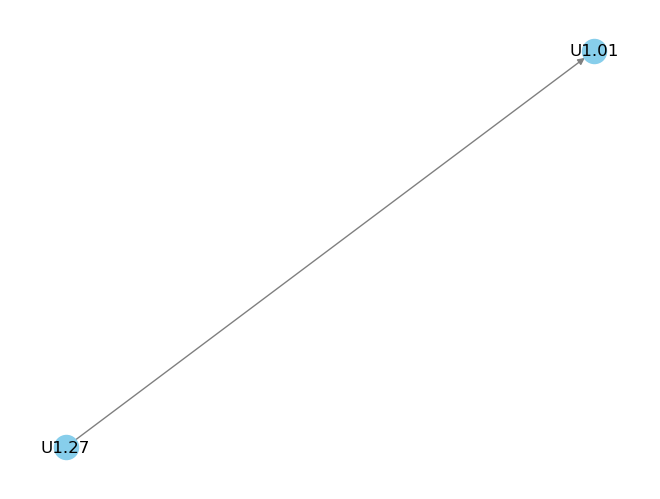

In [19]:
G = nx.DiGraph()
for node in labels['1.A']['nodes']:
    G.add_node(node)

for edge in labels['1.A']['edges']:
    u,v = edge
    G.add_edge(u,v)

nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray')

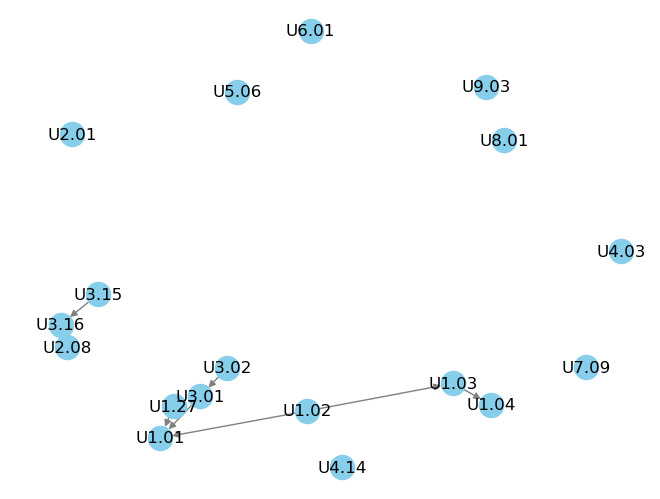

In [20]:
G = nx.DiGraph()
for node in labels['2.A']['nodes']:
    G.add_node(node)

for edge in labels['2.A']['edges']:
    u,v = edge
    G.add_edge(u,v)

nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray')